# SentinelFrame — DINOv2 Inference Demo

Upload one image and a trained DINOv2 checkpoint (`best_model_dinov2.pt`, produced by the "10a. DINOv2 ViT-B/14" section of `finetune_openclip_lora.ipynb`), and watch every pipeline step run on that single image:

```
raw image -> YOLO person detection -> expand box -> crop -> letterbox 224x224 -> DINOv2+LoRA classifier -> logits / probabilities / final answer
```

**Architecture reproduced exactly to match the checkpoint** (must match cell 10a in the training notebook or `load_state_dict` will fail on a key mismatch):
- Backbone: `dinov2_vitb14` via `torch.hub`, frozen, embed dim 768.
- LoRA target modules are *discovered* from the model at runtime (`qkv`, `proj`, `fc1`, `fc2`) rather than hardcoded, the same way the training notebook does — this only works because the discovery is deterministic given the fixed architecture, so it reliably reproduces the exact same LoRA module names/keys the checkpoint was saved with.
- Head: `Linear(768→256) → ReLU → Dropout(0.2) → Linear(256→NUM_LABELS)`.
- Preprocessing: ImageNet normalization (`mean=(0.485,0.456,0.406)`, `std=(0.229,0.224,0.225)`), **not** CLIP's — DINOv2 was trained with its own stats.

`LABELS` is hardcoded below (not imported from `generate_images.py` like the training notebook) so this demo doesn't need an extra file upload just to run — double-check it matches what the checkpoint was actually trained on if you've changed the label set since.

In [1]:
!pip install -q ultralytics opencv-python-headless peft pillow matplotlib numpy
# PEFT's LoRA module-dispatch logic checks the installed torchao version even when
# torchao itself isn't otherwise used (plain nn.Linear LoRA doesn't need it) — Colab's
# preinstalled torchao (0.10.0) is older than what current peft requires (>=0.16.0),
# which makes get_peft_model() raise ImportError: "Found an incompatible version of
# torchao". Upgrading it here avoids that; must happen before peft/torch get imported.
!pip install -q -U "torchao>=0.16.0"
# xformers is deliberately NOT installed: torch.hub's dinov2 code already falls back to
# standard attention when xformers isn't importable, and pip-installed xformers wheels on
# Colab are frequently ABI-incompatible with Colab's preinstalled torch build.
# If torch/torchvision aren't already installed (e.g. a fresh environment), uncomment —
# leave commented if you already have a CUDA-matched torch build, to avoid clobbering it:
# !pip install -q torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import shutil


drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/checkpoints.zip'
extract_to = '/content/checkpoints'


shutil.unpack_archive(zip_path, extract_to, 'zip')

Mounted at /content/drive


In [3]:
import sys

import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO
from peft import LoraConfig, get_peft_model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# ============================================================
# Configuration
# ============================================================

# Must match the label order the checkpoint was trained with (generate_images.py's LABELS).
LABELS = [
    "hand_in_pocket",
    "hand_in_bag",
    "hand_under_clothing",
    "object_in_hand",
    "interacting_with_shelf",
    "hand_occluded_generic",
    "both_hands_not_visible",
    "no_visible_hand_interaction",
]
NUM_LABELS = len(LABELS)

IMAGE_SIZE = 224
DINOV2_MODEL_NAME = "dinov2_vitb14"
DINOV2_EMBED_DIM = 768

YOLO_MODEL = "yolov8n.pt"
CONF_THRESHOLD = 0.25
EXPANSION_FACTOR = 0.30

LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

CLASSIFICATION_THRESHOLD = 0.5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Labels ({NUM_LABELS}): {LABELS}")

Device: cpu
Labels (8): ['hand_in_pocket', 'hand_in_bag', 'hand_under_clothing', 'object_in_hand', 'interacting_with_shelf', 'hand_occluded_generic', 'both_hands_not_visible', 'no_visible_hand_interaction']


## 1. Upload the image and the checkpoint

In [15]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import files

    print("Upload the image to classify:")
    uploaded_image = files.upload()
    IMAGE_PATH = next(iter(uploaded_image))

    print("\nUpload the trained checkpoint (best_model_dinov2.pt):")
    # uploaded_ckpt = files.upload()
    CHECKPOINT_PATH = "/content/checkpoints/best_model_dinov2.pt" #next(iter(uploaded_ckpt))
else:
    # Not running in Colab — set these manually instead of uploading.
    IMAGE_PATH = "/path/to/your/image.jpg"
    CHECKPOINT_PATH = "/path/to/best_model_dinov2.pt"

print(f"\nImage: {IMAGE_PATH}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Upload the image to classify:


Saving תמונה1.jpg to תמונה1.jpg

Upload the trained checkpoint (best_model_dinov2.pt):

Image: תמונה1.jpg
Checkpoint: /content/checkpoints/best_model_dinov2.pt


## 2. Raw image

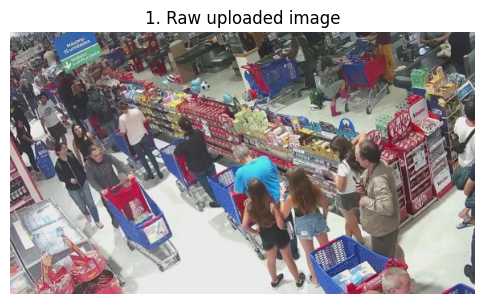

In [16]:
raw_bgr = cv2.imread(IMAGE_PATH)
if raw_bgr is None:
    raise FileNotFoundError(f"Could not read image at {IMAGE_PATH}")

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB))
plt.title("1. Raw uploaded image")
plt.axis("off")
plt.show()

## 3. YOLO person detection

If more than one person is detected, only the highest-confidence box is used — matching the convention used throughout the rest of the project (every generated/real image is expected to contain exactly one relevant person).

⚠ 12 people detected; using the highest-confidence box.
Person detected with confidence 0.842 at (133, 85, 191, 184)


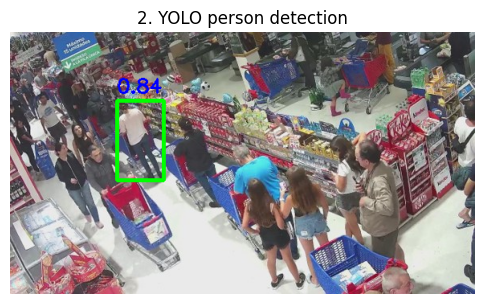

In [17]:
yolo_model = YOLO(YOLO_MODEL)
result = yolo_model.predict(source=IMAGE_PATH, conf=CONF_THRESHOLD, classes=[0], verbose=False)[0]

boxes = result.boxes
if len(boxes) == 0:
    raise RuntimeError("No person detected in the uploaded image — try a clearer, closer shot.")
if len(boxes) > 1:
    print(f"⚠ {len(boxes)} people detected; using the highest-confidence box.")

best_box = max(boxes, key=lambda b: float(b.conf[0]))
x1, y1, x2, y2 = best_box.xyxy[0].cpu().numpy().astype(int)
confidence = float(best_box.conf[0])
print(f"Person detected with confidence {confidence:.3f} at ({x1}, {y1}, {x2}, {y2})")

annotated = raw_bgr.copy()
cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 3)
cv2.putText(annotated, f"{confidence:.2f}", (x1, max(30, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("2. YOLO person detection")
plt.axis("off")
plt.show()

## 4. Expand the bounding box

Original box: (133, 85, 191, 184)
Expanded box: (125, 71, 199, 198)


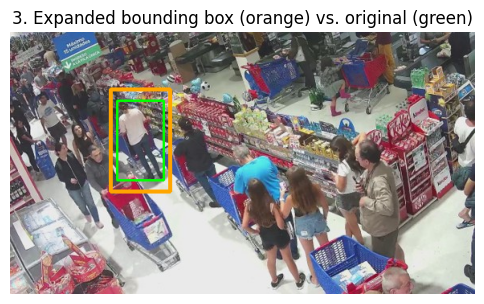

In [18]:
def expand_bbox(x1, y1, x2, y2, image_width, image_height, expansion=0.2):
    """Expand a bounding box by `expansion` fraction of its size, clamped to image bounds."""
    w, h = x2 - x1, y2 - y1
    dw, dh = int(w * expansion / 2), int(h * expansion / 2)
    return (
        max(0, x1 - dw),
        max(0, y1 - dh),
        min(image_width, x2 + dw),
        min(image_height, y2 + dh),
    )


img_h, img_w = raw_bgr.shape[:2]
ex1, ey1, ex2, ey2 = expand_bbox(x1, y1, x2, y2, img_w, img_h, EXPANSION_FACTOR)
print(f"Original box: ({x1}, {y1}, {x2}, {y2})")
print(f"Expanded box: ({ex1}, {ey1}, {ex2}, {ey2})")

expanded_view = raw_bgr.copy()
cv2.rectangle(expanded_view, (x1, y1), (x2, y2), (0, 255, 0), 2)        # original, green
cv2.rectangle(expanded_view, (ex1, ey1), (ex2, ey2), (0, 165, 255), 3)  # expanded, orange

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(expanded_view, cv2.COLOR_BGR2RGB))
plt.title("3. Expanded bounding box (orange) vs. original (green)")
plt.axis("off")
plt.show()

## 5. Crop the person region

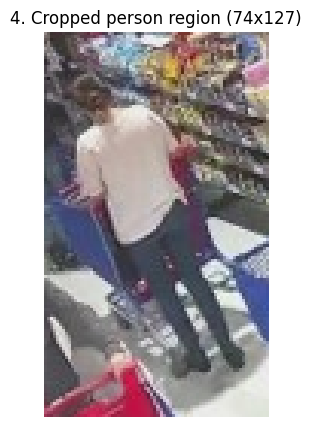

In [19]:
crop = raw_bgr[ey1:ey2, ex1:ex2]
if crop.size == 0:
    raise RuntimeError("Degenerate crop (zero area) after expanding the bounding box.")

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title(f"4. Cropped person region ({crop.shape[1]}x{crop.shape[0]})")
plt.axis("off")
plt.show()

## 6. Letterbox resize to 224x224

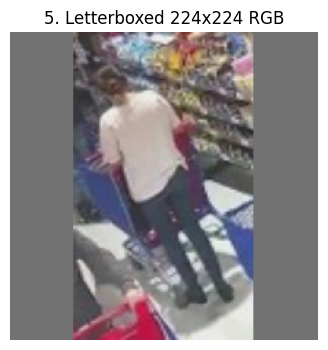

In [20]:
def letterbox(image, target_size=224, color=(114, 114, 114)):
    """Resize preserving aspect ratio and pad to a target_size square, YOLO-style."""
    h, w = image.shape[:2]
    scale = min(target_size / w, target_size / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((target_size, target_size, 3), color, dtype=np.uint8)

    pad_x, pad_y = (target_size - new_w) // 2, (target_size - new_h) // 2
    canvas[pad_y:pad_y + new_h, pad_x:pad_x + new_w] = resized
    return canvas


letterboxed = letterbox(crop, IMAGE_SIZE)

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(letterboxed, cv2.COLOR_BGR2RGB))
plt.title(f"5. Letterboxed {IMAGE_SIZE}x{IMAGE_SIZE} RGB")
plt.axis("off")
plt.show()

## 7. Load the DINOv2 + LoRA classifier and the trained checkpoint

Instantiating `dinov2_vitb14` still needs a one-time network fetch of the base architecture/default weights via `torch.hub` — those default weights are then fully overwritten by `load_state_dict()` below, so the actual predictions come entirely from your uploaded checkpoint, not from the hub download.

In [21]:
try:
    dino_backbone = torch.hub.load("facebookresearch/dinov2", DINOV2_MODEL_NAME, trust_repo=True)
except TypeError:
    dino_backbone = torch.hub.load("facebookresearch/dinov2", DINOV2_MODEL_NAME)

for p in dino_backbone.parameters():
    p.requires_grad = False


def discover_lora_targets(module, suffixes=("qkv", "proj", "fc1", "fc2")):
    found = set()
    for name, sub in module.named_modules():
        if isinstance(sub, nn.Linear) and name.split(".")[-1] in suffixes:
            found.add(name.split(".")[-1])
    return sorted(found)


lora_targets = discover_lora_targets(dino_backbone)
print(f"LoRA target modules: {lora_targets}")
assert lora_targets, "No Linear submodules matched — inspect dino_backbone's structure."

lora_config = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=lora_targets,
    lora_dropout=LORA_DROPOUT, bias="none",
)
dino_backbone = get_peft_model(dino_backbone, lora_config)


class DINOv2Classifier(nn.Module):
    def __init__(self, backbone, embed_dim, num_labels):
        super().__init__()
        self.base = backbone
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels),
        )

    def forward(self, x):
        features = self.base(x).float()  # dinov2 __call__ -> CLS embedding [B, embed_dim]
        return self.head(features)


model = DINOv2Classifier(dino_backbone, DINOV2_EMBED_DIM, NUM_LABELS).to(DEVICE)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', '?')} "
      f"(val_f1_macro={checkpoint.get('val_f1_macro', float('nan')):.4f})")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


LoRA target modules: ['fc1', 'fc2', 'proj', 'qkv']
Loaded checkpoint from epoch 27 (val_f1_macro=0.9564)


## 8. Classify

ImageNet normalization (DINOv2's own stats, not CLIP's) — no resize needed since the letterboxed crop is already exactly `IMAGE_SIZE`x`IMAGE_SIZE`.

In [22]:
dinov2_normalize = transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
image_transform = transforms.Compose([transforms.ToTensor(), dinov2_normalize])

letterboxed_rgb = cv2.cvtColor(letterboxed, cv2.COLOR_BGR2RGB)
input_tensor = image_transform(Image.fromarray(letterboxed_rgb)).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(input_tensor)[0]
    probabilities = torch.sigmoid(logits)

order = torch.argsort(probabilities, descending=True)

print("Per-label results (sorted by probability):")
for i in order:
    marker = "✓" if probabilities[i] >= CLASSIFICATION_THRESHOLD else " "
    print(f"  [{marker}] {LABELS[i]:<28} logit={logits[i]:+.3f}  prob={probabilities[i]:.4f}")

predicted = [(LABELS[i], float(probabilities[i])) for i in range(NUM_LABELS)
             if probabilities[i] >= CLASSIFICATION_THRESHOLD]

print()
if predicted:
    print(f"Final answer (probability >= {CLASSIFICATION_THRESHOLD:.2f}):")
    for label, prob in predicted:
        print(f"  - {label} ({prob:.4f})")
else:
    top_i = int(order[0])
    print(f"No label crossed the {CLASSIFICATION_THRESHOLD:.2f} threshold. "
          f"Best guess: {LABELS[top_i]} (prob={float(probabilities[top_i]):.4f})")

Per-label results (sorted by probability):
  [✓] no_visible_hand_interaction  logit=+7.547  prob=0.9995
  [ ] hand_occluded_generic        logit=-5.992  prob=0.0025
  [ ] both_hands_not_visible       logit=-8.004  prob=0.0003
  [ ] interacting_with_shelf       logit=-9.288  prob=0.0001
  [ ] hand_in_bag                  logit=-9.393  prob=0.0001
  [ ] hand_in_pocket               logit=-10.461  prob=0.0000
  [ ] hand_under_clothing          logit=-11.087  prob=0.0000
  [ ] object_in_hand               logit=-11.381  prob=0.0000

Final answer (probability >= 0.50):
  - no_visible_hand_interaction (0.9995)


## 9. Full pipeline summary

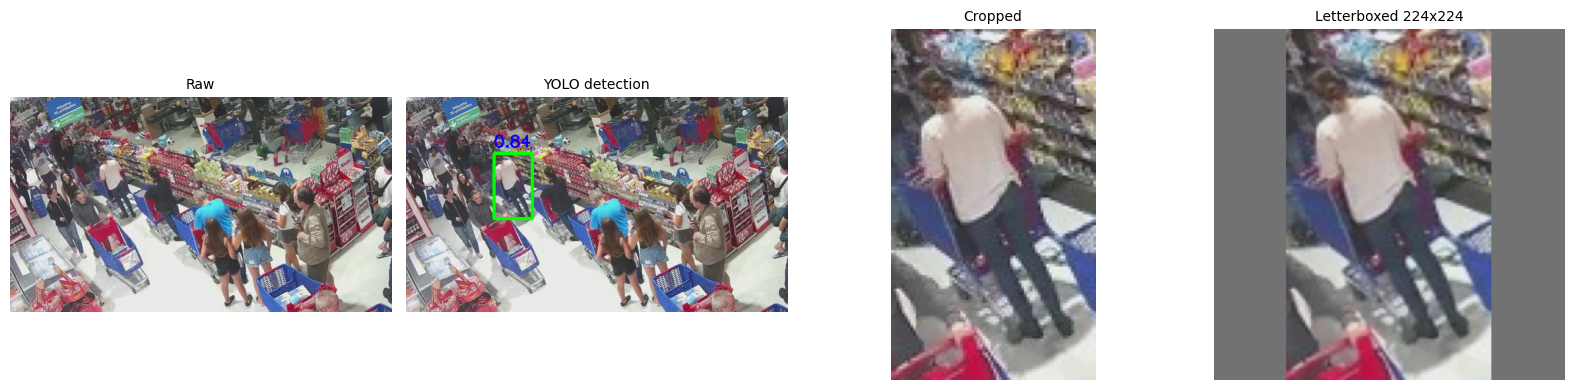

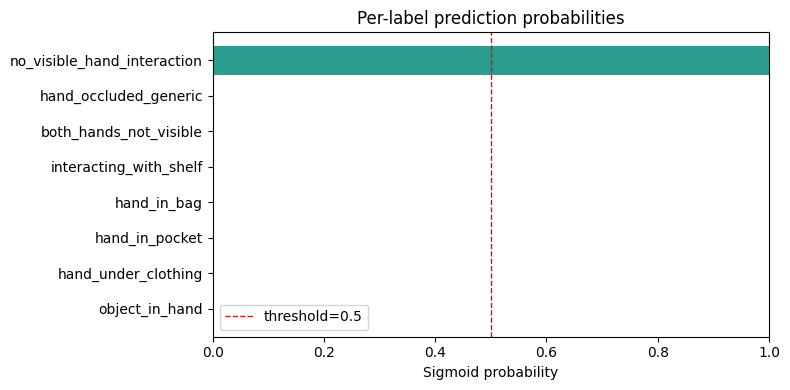

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(
    axes,
    [raw_bgr, annotated, crop, letterboxed],
    ["Raw", "YOLO detection", "Cropped", "Letterboxed 224x224"],
):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

sorted_idx = order.cpu().numpy()
sorted_labels = [LABELS[i] for i in sorted_idx]
sorted_probs = [float(probabilities[i]) for i in sorted_idx]
colors = ["#2a9d8f" if p >= CLASSIFICATION_THRESHOLD else "#adb5bd" for p in sorted_probs]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sorted_labels[::-1], sorted_probs[::-1], color=colors[::-1])
ax.axvline(CLASSIFICATION_THRESHOLD, color="red", linestyle="--", linewidth=1,
           label=f"threshold={CLASSIFICATION_THRESHOLD}")
ax.set_xlim(0, 1)
ax.set_xlabel("Sigmoid probability")
ax.set_title("Per-label prediction probabilities")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Multi-person detection + labeling

Runs the full crop -> letterbox -> classify pipeline independently for **every** person YOLO detects in the raw image (not just the highest-confidence one used in the step-by-step walkthrough above), then draws a green box + predicted label on each one in a single combined image.

Classifying 12 detected person(s)...
  Person 1 (det. conf=0.84): no_visible_hand_interaction
  Person 2 (det. conf=0.79): both_hands_not_visible? (0.18)
  Person 3 (det. conf=0.70): no_visible_hand_interaction? (0.06)
  Person 4 (det. conf=0.68): hand_occluded_generic? (0.21)
  Person 5 (det. conf=0.63): hand_occluded_generic
  Person 6 (det. conf=0.41): no_visible_hand_interaction
  Person 7 (det. conf=0.40): both_hands_not_visible
  Person 8 (det. conf=0.37): object_in_hand? (0.01)
  Person 9 (det. conf=0.29): no_visible_hand_interaction
  Person 10 (det. conf=0.28): hand_occluded_generic? (0.12)
  Person 11 (det. conf=0.28): hand_occluded_generic
  Person 12 (det. conf=0.26): no_visible_hand_interaction


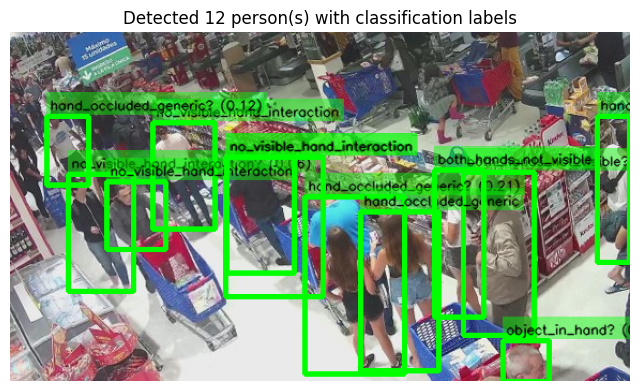

In [28]:
# If True, any detected person whose box overlaps another detected person's box
# (IoU > OVERLAP_IOU_THRESHOLD) is skipped entirely — not classified, not drawn.
# The classifier was only ever trained on crops containing one isolated, unoccluded
# person, so a crop that includes part of a neighboring person is out-of-distribution
# and its prediction can't be trusted; hiding both boxes is the safer default over
# guessing which one to keep.
HIDE_OVERLAPPING_PEOPLE = False
OVERLAP_IOU_THRESHOLD = 0.10


def compute_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter_area = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0.0


def classify_bgr_crop(bgr_crop):
    """Letterbox + classify a single BGR crop, return (predicted_labels, probabilities)."""
    crop_letterboxed = letterbox(bgr_crop, IMAGE_SIZE)
    crop_rgb = cv2.cvtColor(crop_letterboxed, cv2.COLOR_BGR2RGB)
    crop_tensor = image_transform(Image.fromarray(crop_rgb)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        crop_logits = model(crop_tensor)[0]
        crop_probs = torch.sigmoid(crop_logits)

    predicted = [LABELS[j] for j in range(NUM_LABELS) if crop_probs[j] >= CLASSIFICATION_THRESHOLD]
    return predicted, crop_probs


def draw_labeled_box(image, x1, y1, x2, y2, title, color=(0, 255, 0),
                      font_scale=0.4, text_thickness=1, alpha=0.45):
    """Draw a box with a small, semi-transparent label band at its top edge, so
    overlapping people's boxes/labels both stay legible instead of occluding each other."""
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)

    (text_w, text_h), baseline = cv2.getTextSize(title, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness)
    pad = 3
    label_y = y1 - 6 if y1 - 6 - text_h > 0 else y1 + text_h + 6

    overlay = image.copy()
    cv2.rectangle(overlay, (x1, label_y - text_h - baseline - pad), (x1 + text_w + pad * 2, label_y + baseline),
                  color, -1)
    cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0, dst=image)

    cv2.putText(image, title, (x1 + pad, label_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale,
                (0, 0, 0), text_thickness, cv2.LINE_AA)


multi_person_view = raw_bgr.copy()
img_h, img_w = raw_bgr.shape[:2]

all_xyxy = [tuple(b.xyxy[0].cpu().numpy().astype(int)) for b in boxes]

overlapping_indices = set()
if HIDE_OVERLAPPING_PEOPLE:
    for i in range(len(all_xyxy)):
        for j in range(i + 1, len(all_xyxy)):
            if compute_iou(all_xyxy[i], all_xyxy[j]) > OVERLAP_IOU_THRESHOLD:
                overlapping_indices.add(i)
                overlapping_indices.add(j)

if len(boxes) == 0:
    print("No person detected in the raw image.")
else:
    print(f"Classifying {len(boxes)} detected person(s)"
          f"{f', {len(overlapping_indices)} skipped for overlap' if overlapping_indices else ''}...")

for i, box in enumerate(boxes):
    if i in overlapping_indices:
        print(f"  Person {i + 1}: skipped (overlaps another detected person).")
        continue

    bx1, by1, bx2, by2 = all_xyxy[i]
    box_conf = float(box.conf[0])

    bex1, bey1, bex2, bey2 = expand_bbox(bx1, by1, bx2, by2, img_w, img_h, EXPANSION_FACTOR)
    person_crop = raw_bgr[bey1:bey2, bex1:bex2]
    if person_crop.size == 0:
        print(f"  Person {i + 1}: degenerate crop, skipped.")
        continue

    predicted, probs = classify_bgr_crop(person_crop)
    if predicted:
        title = " + ".join(predicted)
    else:
        top_j = int(torch.argmax(probs))
        title = f"{LABELS[top_j]}? ({float(probs[top_j]):.2f})"

    print(f"  Person {i + 1} (det. conf={box_conf:.2f}): {title}")

    # The GREEN box drawn is the original (tight) detection box, not the expanded one
    # used internally for cropping — that's what a viewer expects "around the person".
    draw_labeled_box(multi_person_view, bx1, by1, bx2, by2, title)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(multi_person_view, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(boxes)} person(s) with classification labels")
plt.axis("off")
plt.show()